# BESS Dispatch Analysis

This notebook runs the BESS (Battery Energy Storage System) strategy over the same period as the virtual trading backtest and analyses dispatch behaviour across four sections:

1. **Performance Summary** — Net PnL, Sharpe ratio, max drawdown, and degradation cost
2. **Revenue Decomposition** — Component-level PnL breakdown, waterfall chart, and degradation vs. revenue
3. **Dispatch Behaviour** — Price-dispatch-SOC showcase, SOC heatmap, rebalancing impact, and dispatch efficiency
4. **Risk Profile** — Executive summary with PnL waterfall, dispatch duration curve, and daily PnL distribution

The strategy uses LP optimisation (PuLP/HiGHS) for Day-Ahead scheduling and an Opportunity-Cost intraday engine with dynamic cycle capping for real-time adjustments. The DA schedule is optimised against an **ML DA price forecast** loaded from the artifact directory, matching production pipeline behaviour. If no trained BESS model is found, the notebook falls back to realised DA prices (oracle upper bound).

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import json as _json
import sys
from pathlib import Path

import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.bess.bess_asset import BESSAsset
from src.bess.da_optimizer import optimize_da_schedule
from src.bess.intraday_manager import run_intraday_session
from src.utils.config import load_config

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})

COLORS = {
    "da":          "#2196F3",
    "intraday":    "#4CAF50",
    "imbalance":   "#F44336",
    "degradation": "#FF9800",
    "net":         "#9E9E9E",
}

_best_run_path = REPO_ROOT / "artifacts" / "da_positioning" / "best_run.json"
_best_run = (
    _json.loads(_best_run_path.read_text())["best_run"]
    if _best_run_path.exists() else "s4_n10_t50_tc10"
)
ARTIFACT_DIR     = REPO_ROOT / "artifacts" / "da_positioning" / _best_run
STARTING_CAPITAL = 50_000.0

# Load config — fall back to example template if local config.yaml is absent
_cfg_path     = REPO_ROOT / "configs" / "config.yaml"
_cfg_fallback = REPO_ROOT / "configs" / "config.example.yaml"
config   = load_config(_cfg_path if _cfg_path.exists() else _cfg_fallback)
BESS_CFG = config["bess"]

# Load the trained BESS DA price model if present
_model_path = ARTIFACT_DIR / "bess" / "model" / "model.joblib"
_meta_path  = ARTIFACT_DIR / "bess" / "model" / "metadata.json"
if _model_path.exists() and _meta_path.exists():
    DA_FORECAST_MODEL    = joblib.load(_model_path)
    DA_FORECAST_FEATURES = _json.loads(_meta_path.read_text())["features"]
    USE_ML_FORECAST      = True
    print(f"Using artifact      : {_best_run}")
    print(f"DA forecast model loaded ({len(DA_FORECAST_FEATURES)} features)")
else:
    DA_FORECAST_MODEL    = None
    DA_FORECAST_FEATURES = []
    USE_ML_FORECAST      = False
    print(f"Using artifact      : {_best_run}")
    print("WARNING: No BESS model found — falling back to oracle (realised) DA prices")


Using artifact      : s4_n10_t50_tc10


---
## Helpers

Reusable data-loading functions. All paths resolve against `ARTIFACT_DIR` set above.

In [2]:
def load_features() -> pd.DataFrame:
    """Load the feature/price parquet from the shared artifact."""
    df = pd.read_parquet(ARTIFACT_DIR / "features" / "features.parquet")
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df.set_index("time").sort_index()


def load_virtual_signals() -> pd.DataFrame:
    """Load virtual strategy signals CSV from the shared artifact."""
    df = pd.read_csv(
        ARTIFACT_DIR / "virtual" / "trading" / "signals.csv",
        parse_dates=["delivery_time"],
    )
    df["delivery_time"] = pd.to_datetime(df["delivery_time"], utc=True)
    return df


def load_virtual_pnl() -> pd.DataFrame:
    """Load virtual strategy PnL CSV from the shared artifact."""
    df = pd.read_csv(
        ARTIFACT_DIR / "virtual" / "trading" / "pnl.csv",
        parse_dates=["time"],
    )
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df

---
## Data Loading

Load the feature/price dataset and the virtual signals from the shared artifact. The analysis period is pinned to the virtual strategy's walk-forward test window so both strategies are evaluated on identical dates.

In [3]:
features_df = load_features()

# Derive the analysis period from the virtual signals (walk-forward test window)
_signals = load_virtual_signals()
ANALYSIS_START = _signals["delivery_time"].min()
ANALYSIS_END   = _signals["delivery_time"].max()

# Filter features to the analysis period
features_period = features_df.loc[ANALYSIS_START:ANALYSIS_END]

# Resample to hourly â BESS LP and intraday manager operate at 1-hour resolution.
# MID is loaded for settlement only: the engine decides on the DA proxy and settles
# the committed deviations at the real observed MID.
prices = (
    features_period[["day_ahead_price", "mid_price", "system_buy_price", "system_sell_price"]]
    .resample("1h").mean()
    .dropna()
)

# BESSAsset asset kwargs
_ASSET_FIELDS = {"capacity_mwh", "power_mw", "charge_efficiency",
                 "discharge_efficiency", "degradation_cost_per_mwh", "initial_soc_pct",
                 "min_soc_pct", "max_soc_pct"}
asset_kwargs = {k: v for k, v in BESS_CFG.items() if k in _ASSET_FIELDS}

# SOC bounds and daily cycle cap drive the LP and the chart limit lines below
MIN_SOC_PCT         = BESS_CFG.get("min_soc_pct", 0.0)
MAX_SOC_PCT         = BESS_CFG.get("max_soc_pct", 1.0)
TARGET_DAILY_CYCLES = BESS_CFG.get("target_daily_cycles")

features_period_london = features_period.copy()
features_period_london.index = features_period_london.index.tz_convert("Europe/London")

print(f"Analysis period : {ANALYSIS_START.date()} → {ANALYSIS_END.date()}")
print(f"Price rows (1h) : {len(prices)}")
print(f"Feature rows    : {len(features_period)}")
print(f"SOC bounds      : {MIN_SOC_PCT:.0%} – {MAX_SOC_PCT:.0%}")
print(f"Daily cycle cap : {TARGET_DAILY_CYCLES if TARGET_DAILY_CYCLES is not None else 'disabled'}")

Analysis period : 2018-07-21 → 2018-12-18
Price rows (1h) : 3513
Feature rows    : 7202
SOC bounds      : 10% – 90%
Daily cycle cap : 1.5


---
## BESS Backtest

Run the BESS pipeline day-by-day over the analysis period. The DA schedule is solved by LP against the **ML DA price forecast** (loaded from the artifact), matching production pipeline behaviour. Intraday rules execute against MID and imbalance prices in the delivery window. Falls back to realised DA prices if no trained model is present.

In [4]:
daily_results    = []
all_dispatch_logs = []
all_da_schedules  = []

# Persistent asset — SOC carries over day-to-day instead of resetting to 50%
asset        = BESSAsset(**asset_kwargs)
prev_soc_pct = None

for date, day_df in prices.groupby(prices.index.date):
    n_hours = len(day_df)
    if n_hours not in {23, 24, 25}:
        continue

    da_prices  = day_df["day_ahead_price"].tolist()
    mid_prices = day_df["mid_price"].tolist()
    sbp_prices = day_df["system_buy_price"].tolist()
    ssp_prices = day_df["system_sell_price"].tolist()

    # DA schedule: use ML forecast when model is available, else oracle (realised) prices
    if USE_ML_FORECAST:
        day_feat = features_period.loc[
            features_period.index.date == date, DA_FORECAST_FEATURES
        ].dropna()
        if len(day_feat) >= n_hours * 2:
            raw_fc = DA_FORECAST_MODEL.predict(day_feat).tolist()
            da_forecast = [
                (raw_fc[i] + raw_fc[i + 1]) / 2
                for i in range(0, n_hours * 2, 2)
            ]
        else:
            da_forecast = da_prices
    else:
        da_forecast = da_prices

    carry_soc = prev_soc_pct if prev_soc_pct is not None else BESS_CFG["initial_soc_pct"]
    asset.reset(soc_pct=carry_soc)
    schedule = optimize_da_schedule(
        da_forecast, asset, target_daily_cycles=TARGET_DAILY_CYCLES
    )

    asset.reset(soc_pct=carry_soc)
    # The intraday market is continuous: each period's MID is observed as it
    # becomes visible. The engine prices the current period at its observed MID and
    # the unseen future at a hurdled DA proxy, executing only the visible period.
    result = run_intraday_session(
        da_schedule=schedule,
        da_price_actual=da_prices,
        mid_prices=mid_prices,
        imbalance_prices=sbp_prices,
        asset=asset,
        config=BESS_CFG,
        imbalance_sell_prices=ssp_prices,
    )
    prev_soc_pct = asset.soc_pct

    daily_results.append({
        "date":                      pd.Timestamp(date),
        "intraday_pnl":              result["intraday_pnl"],
        "cycles_saved_mwh":          result["cycles_saved_mwh"],
        "imbalance_pnl":             result["imbalance_pnl"],
        "degradation_cost":          result["total_degradation_cost"],
        # Trader's-alpha ledger buckets: frozen DA benchmark + consolidated intraday
        # improvement, execution friction isolated; these sum to net_pnl.
        "benchmark_da_revenue":      result["benchmark_da_revenue"],
        "intraday_da_improvement":   result["intraday_da_improvement"],
        "execution_costs_paid":      result["execution_costs_paid"],
        "net_pnl":                   result["net_pnl"],
    })

    for entry in result["dispatch_log"]:
        entry["date"] = date
        entry["hour"] = entry["period"]
        entry["timestamp"] = day_df.index[entry["period"]]
    all_dispatch_logs.extend(result["dispatch_log"])

    for h, mw in enumerate(schedule):
        all_da_schedules.append({
            "date":      date,
            "hour":      h,
            "timestamp": day_df.index[h],
            "da_mw":     mw,
        })

results_df  = pd.DataFrame(daily_results)
dispatch_df = pd.DataFrame(all_dispatch_logs)
da_sched_df = pd.DataFrame(all_da_schedules)

print(f"Backtest complete : {len(results_df)} days")
print(f"Total net PnL     : £{results_df['net_pnl'].sum():,.0f}")
print(f"Mean daily PnL    : £{results_df['net_pnl'].mean():,.0f}")

Backtest complete : 144 days
Total net PnL     : £286,346
Mean daily PnL    : £1,989


---
## Section 1: Performance Summary

Key risk-return metrics for the BESS strategy over the full backtest period.

In [5]:
avg_daily   = results_df["net_pnl"].mean()
std_daily   = results_df["net_pnl"].std(ddof=1)
total_net   = results_df["net_pnl"].sum()
total_ret   = total_net / STARTING_CAPITAL
sharpe      = (avg_daily / std_daily) * np.sqrt(365) if std_daily > 0 else 0.0

cumulative  = results_df["net_pnl"].cumsum()
peak        = cumulative.cummax()
max_dd      = (cumulative - peak).min()
calmar      = total_ret / (abs(max_dd) / STARTING_CAPITAL) if max_dd < 0 else float("nan")

neg_ret     = results_df.loc[results_df["net_pnl"] < 0, "net_pnl"]
downside    = np.sqrt((neg_ret ** 2).mean()) if len(neg_ret) > 0 else float("nan")
sortino     = (avg_daily / downside) * np.sqrt(365) if (downside and downside > 0) else float("nan")

win_rate    = (results_df["net_pnl"] > 0).mean()
avg_win     = results_df.loc[results_df["net_pnl"] > 0, "net_pnl"].mean()
avg_loss    = results_df.loc[results_df["net_pnl"] < 0, "net_pnl"].mean()

total_deg   = results_df["degradation_cost"].sum()
deg_per_mwh = BESS_CFG["degradation_cost_per_mwh"]
throughput  = total_deg / deg_per_mwh if deg_per_mwh > 0 else 0.0
cycles      = throughput / (2 * BESS_CFG["capacity_mwh"]) if BESS_CFG["capacity_mwh"] > 0 else 0.0
net_per_mwh = total_net / throughput if throughput > 0 else float("nan")
cap_factor  = throughput / (BESS_CFG["power_mw"] * 24 * len(results_df)) if results_df.shape[0] > 0 else float("nan")

_fmt = lambda v, f: f if not (isinstance(v, float) and np.isnan(v)) else "—"
summary = pd.DataFrame({
    "Metric": [
        "Net PnL",            "Total Return",        "Sharpe (ann.)",
        "Calmar Ratio",       "Sortino Ratio",        "Max Drawdown",
        "Win Rate",           "Avg Win Day",          "Avg Loss Day",
        "Days Traded",        "MWh Throughput",       "Total Cycles",
        "Net £/MWh",          "Degradation Cost",     "Capacity Factor",
    ],
    "Value": [
        f"£{total_net:,.0f}",
        f"{total_ret:+.1%}",
        _fmt(sharpe,      f"{sharpe:.2f}"),
        _fmt(calmar,      f"{calmar:.2f}"),
        _fmt(sortino,     f"{sortino:.2f}"),
        f"£{max_dd:,.0f}",
        f"{win_rate:.1%}",
        _fmt(avg_win,     f"£{avg_win:,.0f}"),
        _fmt(avg_loss,    f"£{avg_loss:,.0f}"),
        f"{len(results_df)}",
        f"{throughput:,.0f} MWh",
        f"{cycles:.1f}",
        _fmt(net_per_mwh, f"£{net_per_mwh:.2f}/MWh"),
        f"£{total_deg:,.0f}",
        _fmt(cap_factor,  f"{cap_factor:.1%}"),
    ],
}).set_index("Metric")

summary.style.set_properties(**{"text-align": "right"})


,Value
Metric,
Net PnL,"£286,346"
Total Return,+572.7%
Sharpe (ann.),30.38
Calmar Ratio,88.53
Sortino Ratio,20.06
Max Drawdown,"£-3,234"
Win Rate,97.9%
Avg Win Day,"£2,059"
Avg Loss Day,"£-1,321"


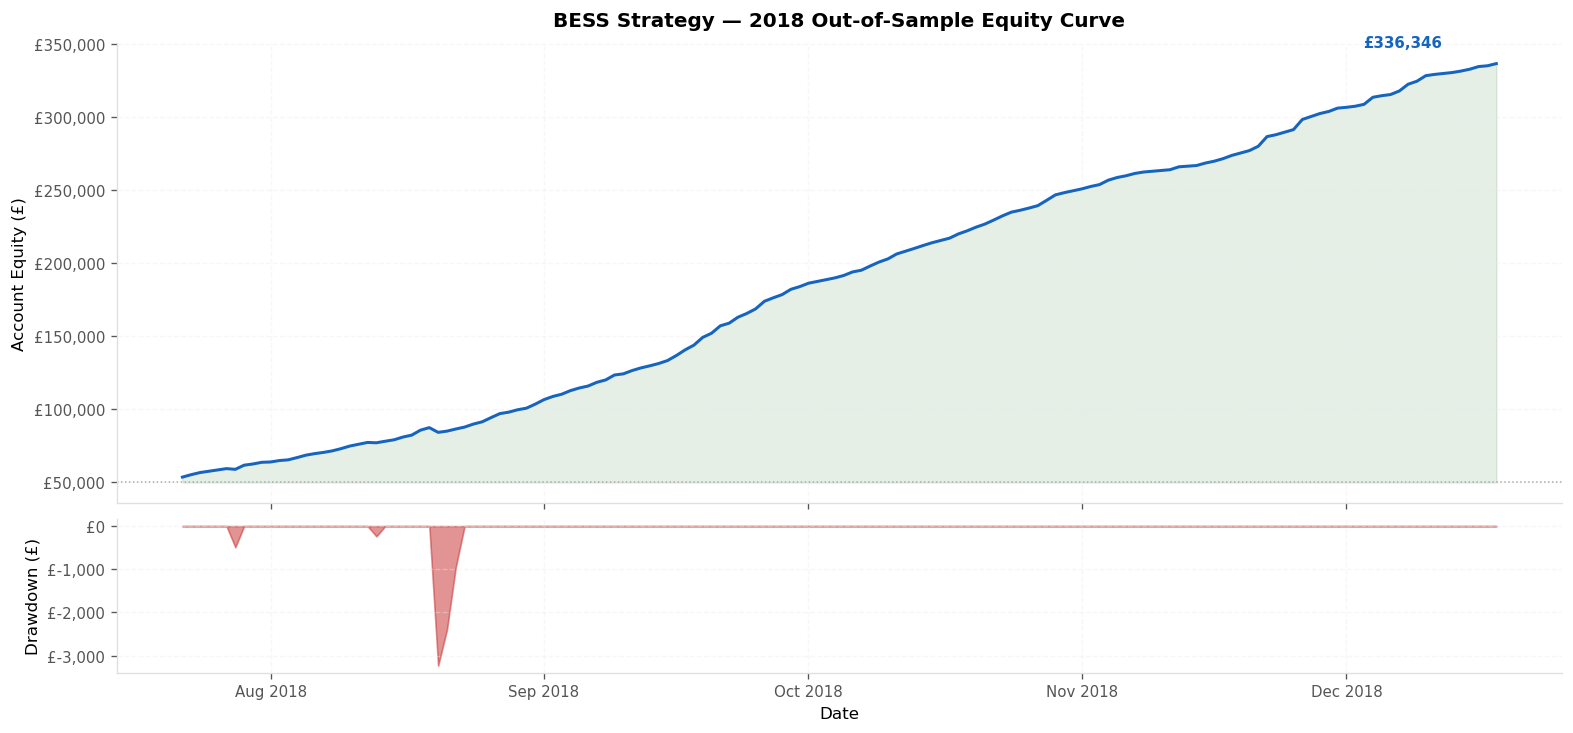

In [6]:
# ── Equity curve + drawdown ───────────────────────────────────────────────────
_eq = STARTING_CAPITAL + results_df.set_index("date")["net_pnl"].cumsum()
_dd = _eq - _eq.cummax()

fig, (ax_eq, ax_dd) = plt.subplots(
    2, 1, figsize=(13, 6), sharex=True, layout="constrained",
    gridspec_kw={"height_ratios": [3, 1]},
)
ax_eq.plot(_eq.index, _eq.values, color="#1565C0", linewidth=1.8, zorder=3)
ax_eq.fill_between(_eq.index, STARTING_CAPITAL, _eq.values,
                   where=(_eq.values >= STARTING_CAPITAL), alpha=0.12, color="#2E7D32")
ax_eq.fill_between(_eq.index, STARTING_CAPITAL, _eq.values,
                   where=(_eq.values < STARTING_CAPITAL), alpha=0.15, color="#C62828")
ax_eq.axhline(STARTING_CAPITAL, color="#aaaaaa", linestyle=":", linewidth=0.9)
ax_eq.annotate(f"£{_eq.iloc[-1]:,.0f}",
               xy=(_eq.index[-1], _eq.iloc[-1]),
               xytext=(-80, 10), textcoords="offset points",
               fontsize=9, color="#1565C0", fontweight="bold")
ax_eq.set_ylabel("Account Equity (£)", fontsize=10)
ax_eq.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax_eq.set_title("BESS Strategy — 2018 Out-of-Sample Equity Curve", fontsize=12, fontweight="bold", pad=10)

ax_dd.fill_between(_dd.index, _dd.values, 0, alpha=0.5, color="#C62828")
ax_dd.set_ylabel("Drawdown (£)", fontsize=10)
ax_dd.set_xlabel("Date", fontsize=10)
ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax_dd.xaxis.set_major_locator(mdates.MonthLocator())

for ax in (ax_eq, ax_dd):
    ax.spines["left"].set_color("#e0e0e0")
    ax.spines["bottom"].set_color("#e0e0e0")
    ax.grid(True, alpha=0.4, color="#ebebeb", linestyle="--")
    ax.tick_params(colors="#555555", labelsize=9)

plt.show()


---
## Section 2: Revenue Decomposition

Component-level breakdown of total net PnL using the Trader's-Alpha ledger. Each
row maps directly to a column in `results_df`:

| Component | Source Column |
|---|---|
| DA Benchmark | `benchmark_da_revenue` |
| Intraday DA Improvement | `intraday_da_improvement` |
| Execution Costs | `execution_costs_paid` (sign-flipped) |
| Imbalance Penalty | `imbalance_pnl` |
| Degradation | `degradation_cost` (sign-flipped) |

These five buckets sum exactly to `net_pnl`.

,Amount,Share
Component,,
DA Benchmark,"£429,020",149.8%
Intraday DA Improvement,"£-3,162",-1.1%
Execution Costs,"£-12,462",-4.4%
Imbalance Penalty,£0,0.0%
Degradation,"£-127,050",-44.4%


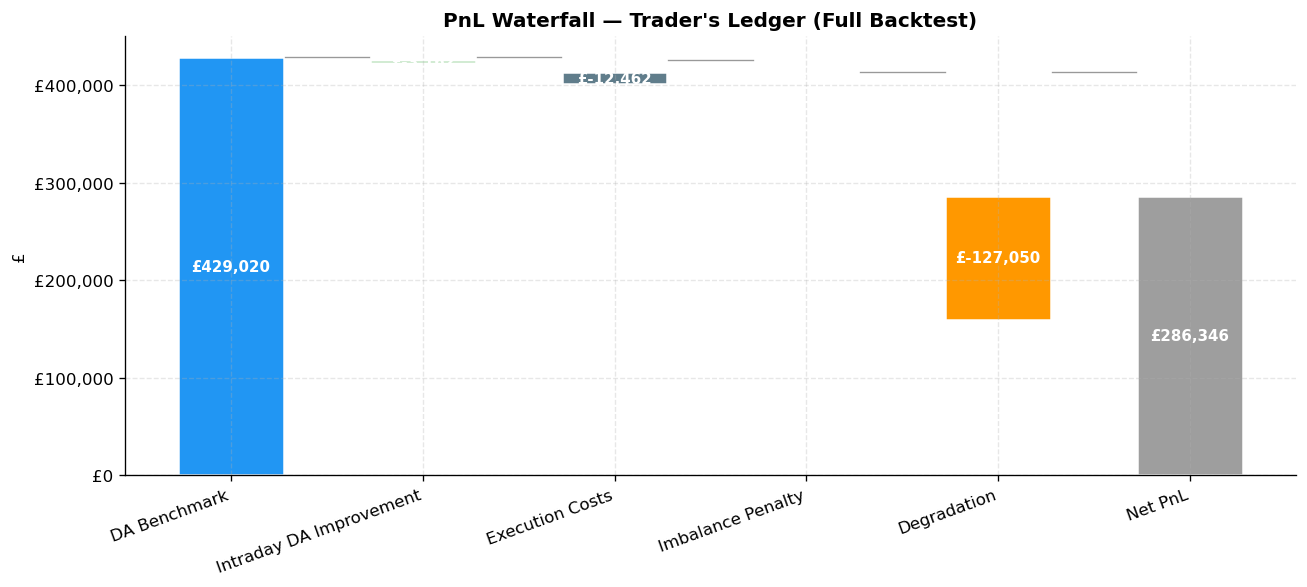

In [7]:
# ── Trader's ledger decomposition: frozen DA benchmark + intraday improvement ──
decomp = pd.DataFrame([
    {"Component": "DA Benchmark",            "Amount": results_df["benchmark_da_revenue"].sum()},
    {"Component": "Intraday DA Improvement", "Amount": results_df["intraday_da_improvement"].sum()},
    {"Component": "Execution Costs",         "Amount": -results_df["execution_costs_paid"].sum()},
    {"Component": "Imbalance Penalty",       "Amount": results_df["imbalance_pnl"].sum()},
    {"Component": "Degradation",             "Amount": -results_df["degradation_cost"].sum()},
]).set_index("Component")

net_pnl = decomp["Amount"].sum()
decomp["Share"] = decomp["Amount"] / abs(net_pnl) * 100

display(
    decomp.style
    .format({"Amount": "£{:,.0f}", "Share": "{:.1f}%"})
    .set_properties(**{"text-align": "right"})
)

# ── Waterfall bridge chart (matches dashboard/charts.py) ──────────────────────
wf_labels = list(decomp.index) + ["Net PnL"]
wf_values = list(decomp["Amount"]) + [net_pnl]

running = 0.0
bottoms = []
for v in list(decomp["Amount"]):
    bottoms.append(running if v >= 0 else running + v)
    running += v
bottoms.append(0.0)

# DA Benchmark and the consolidated intraday improvement carry their own palette
# identity; the cost/settlement buckets reuse the shared COLORS.
bar_colors = [
    COLORS["da"], COLORS["intraday"],
    "#607D8B", COLORS["imbalance"], COLORS["degradation"], COLORS["net"],
]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(range(len(wf_labels)), wf_values, bottom=bottoms,
              color=bar_colors, width=0.55, edgecolor="white", linewidth=1.5)

# Connector lines between bars
running2 = 0.0
for i, v in enumerate(list(decomp["Amount"])):
    top = running2 + v if v >= 0 else running2
    ax.plot([i + 0.28, i + 0.72], [top, top], color="#999999", linewidth=0.8, zorder=4)
    running2 += v

for bar, val in zip(bars, wf_values):
    y = bar.get_y() + bar.get_height() / 2
    ax.text(bar.get_x() + bar.get_width() / 2, y, f"£{val:,.0f}",
            ha="center", va="center", fontsize=9, fontweight="bold", color="white")

ax.set_xticks(range(len(wf_labels)))
ax.set_xticklabels(wf_labels, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("£", fontsize=10)
ax.set_title("PnL Waterfall — Trader's Ledger (Full Backtest)", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.axhline(0, color="#aaaaaa", linewidth=0.6)
plt.tight_layout()
plt.show()

### Monthly Revenue Breakdown

Monthly stacked revenue by settlement layer with cumulative net PnL overlay. Reveals seasonality and month-to-month consistency in the charge/discharge cycle.

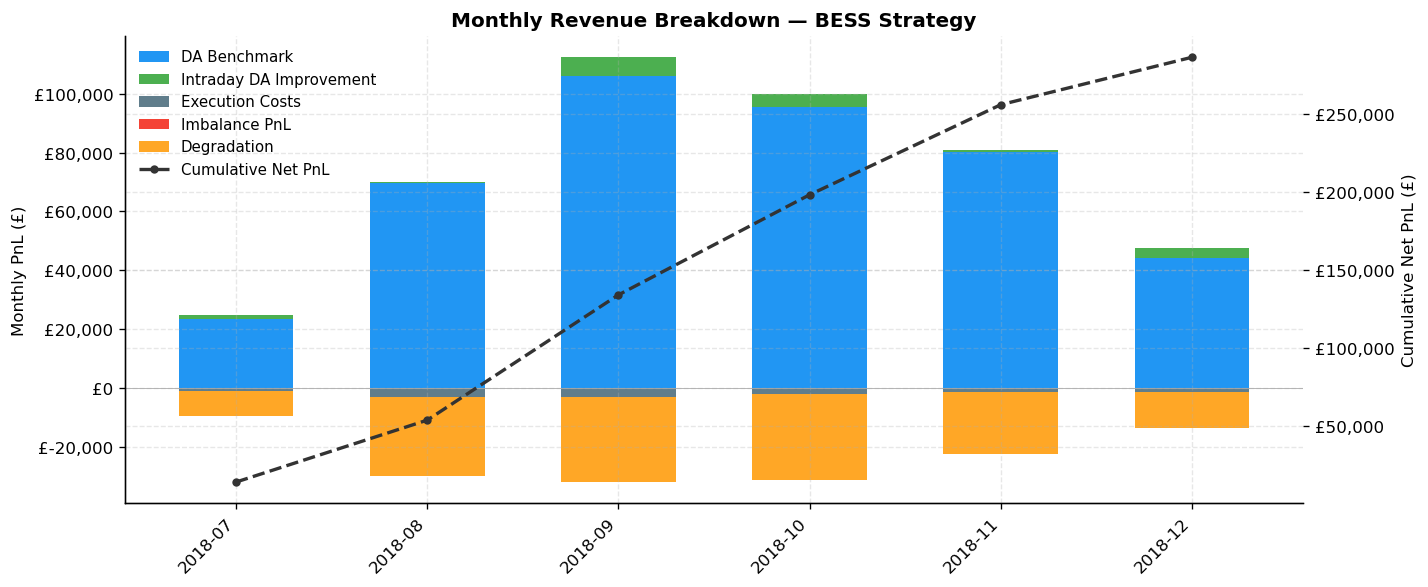

In [8]:
monthly = (
    results_df.assign(month=results_df["date"].dt.to_period("M"))
    .groupby("month")
    .agg(benchmark_da_revenue=("benchmark_da_revenue", "sum"),
         intraday_da_improvement=("intraday_da_improvement", "sum"),
         execution_costs_paid=("execution_costs_paid", "sum"),
         imbalance_pnl=("imbalance_pnl", "sum"),
         degradation_cost=("degradation_cost", "sum"),
         net_pnl=("net_pnl", "sum"))
    .reset_index()
)
monthly["month_str"] = monthly["month"].astype(str)

x = np.arange(len(monthly))
w = 0.6

fig, ax = plt.subplots(figsize=(12, 5))

# DA Benchmark is the base; the consolidated intraday improvement stacks above it.
ax.bar(x, monthly["benchmark_da_revenue"], w, label="DA Benchmark", color=COLORS["da"])
base1 = monthly["benchmark_da_revenue"]
ax.bar(x, monthly["intraday_da_improvement"], w, bottom=base1,
       label="Intraday DA Improvement", color=COLORS["intraday"])

# Execution friction, imbalance and degradation stack below zero as deductions.
neg1 = -monthly["execution_costs_paid"]
ax.bar(x, neg1, w, label="Execution Costs", color="#607D8B")
neg2 = monthly["imbalance_pnl"]
ax.bar(x, neg2, w, bottom=neg1, label="Imbalance PnL", color=COLORS["imbalance"])
neg3 = -monthly["degradation_cost"]
ax.bar(x, neg3, w, bottom=neg1 + neg2, label="Degradation",
       color=COLORS["degradation"], alpha=0.85)

# Cumulative net PnL on right axis
ax2 = ax.twinx()
ax2.plot(x, monthly["net_pnl"].cumsum(), color="#333333", linewidth=2,
         linestyle="--", marker="o", markersize=4, label="Cumulative Net PnL")
ax2.set_ylabel("Cumulative Net PnL (£)", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"£{v:,.0f}"))
ax2.spines["top"].set_visible(False)

ax.set_xticks(x)
ax.set_xticklabels(monthly["month_str"], rotation=45, ha="right")
ax.set_ylabel("Monthly PnL (£)", fontsize=10)
ax.set_title("Monthly Revenue Breakdown — BESS Strategy", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"£{v:,.0f}"))
ax.axhline(0, color="#aaaaaa", linewidth=0.5)

h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

### Degradation vs. Gross Revenue

Cumulative degradation cost plotted against cumulative gross revenue (DA + intraday + imbalance). The gap is the net benefit of battery cycling.

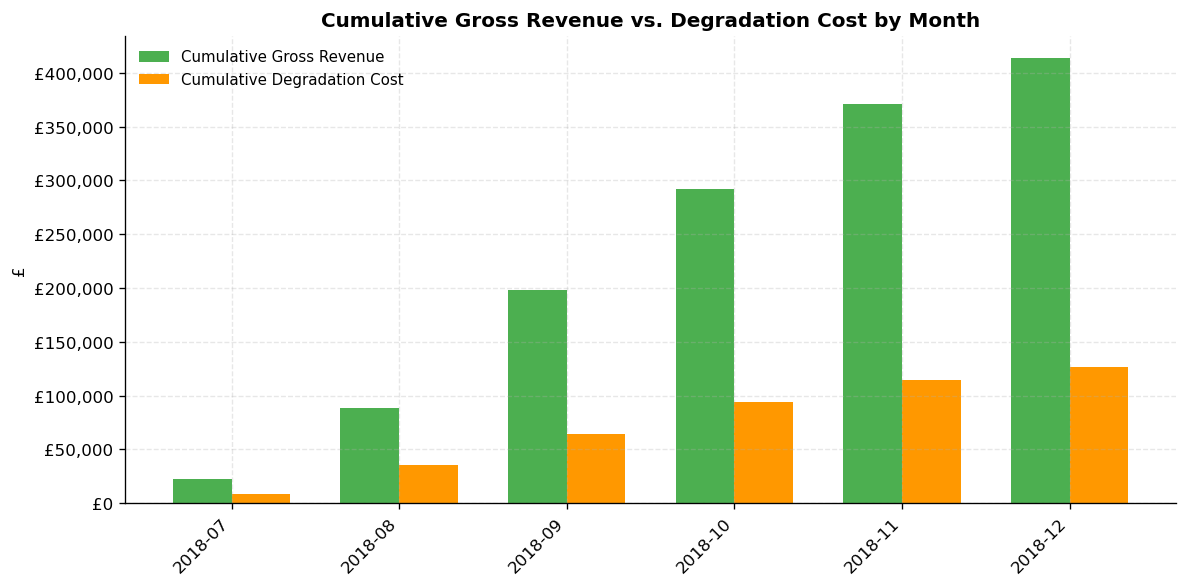

Net benefit of cycles : £286,346
Gross revenue         : £413,396
Degradation cost      : £127,050
Gross/Degradation     : 3.3×


In [9]:
_monthly = (
    results_df.assign(month=results_df["date"].dt.to_period("M"))
    .groupby("month")
    .agg(benchmark=("benchmark_da_revenue", "sum"),
         improvement=("intraday_da_improvement", "sum"),
         execution=("execution_costs_paid", "sum"),
         imbalance=("imbalance_pnl", "sum"),
         deg=("degradation_cost", "sum"))
    .reset_index()
)
# Gross revenue = DA benchmark + intraday improvement − execution + imbalance
# (everything except the degradation cost the cycling itself incurs).
_monthly["gross"] = (
    _monthly["benchmark"] + _monthly["improvement"]
    - _monthly["execution"] + _monthly["imbalance"]
)
_monthly["cum_gross"] = _monthly["gross"].cumsum()
_monthly["cum_deg"]   = _monthly["deg"].cumsum()
_monthly["month_str"] = _monthly["month"].astype(str)

x = np.arange(len(_monthly))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w/2, _monthly["cum_gross"], w, label="Cumulative Gross Revenue", color=COLORS["intraday"])
ax.bar(x + w/2, _monthly["cum_deg"],   w, label="Cumulative Degradation Cost", color=COLORS["degradation"])
ax.set_xticks(x)
ax.set_xticklabels(_monthly["month_str"], rotation=45, ha="right")
ax.set_ylabel("£", fontsize=10)
ax.set_title("Cumulative Gross Revenue vs. Degradation Cost by Month", fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"£{v:,.0f}"))
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

net_benefit = _monthly["cum_gross"].iloc[-1] - _monthly["cum_deg"].iloc[-1]
print(f"Net benefit of cycles : £{net_benefit:,.0f}")
print(f"Gross revenue         : £{_monthly['cum_gross'].iloc[-1]:,.0f}")
print(f"Degradation cost      : £{_monthly['cum_deg'].iloc[-1]:,.0f}")
print(f"Gross/Degradation     : {_monthly['cum_gross'].iloc[-1] / _monthly['cum_deg'].iloc[-1]:.1f}×")

---
## Section 3: Dispatch Behaviour

Analysis of the BESS dispatch strategy across multiple dimensions: the core charge/discharge logic on a representative day, SOC health across all backtest days, rebalancing impact, and DA-to-actual dispatch fidelity.

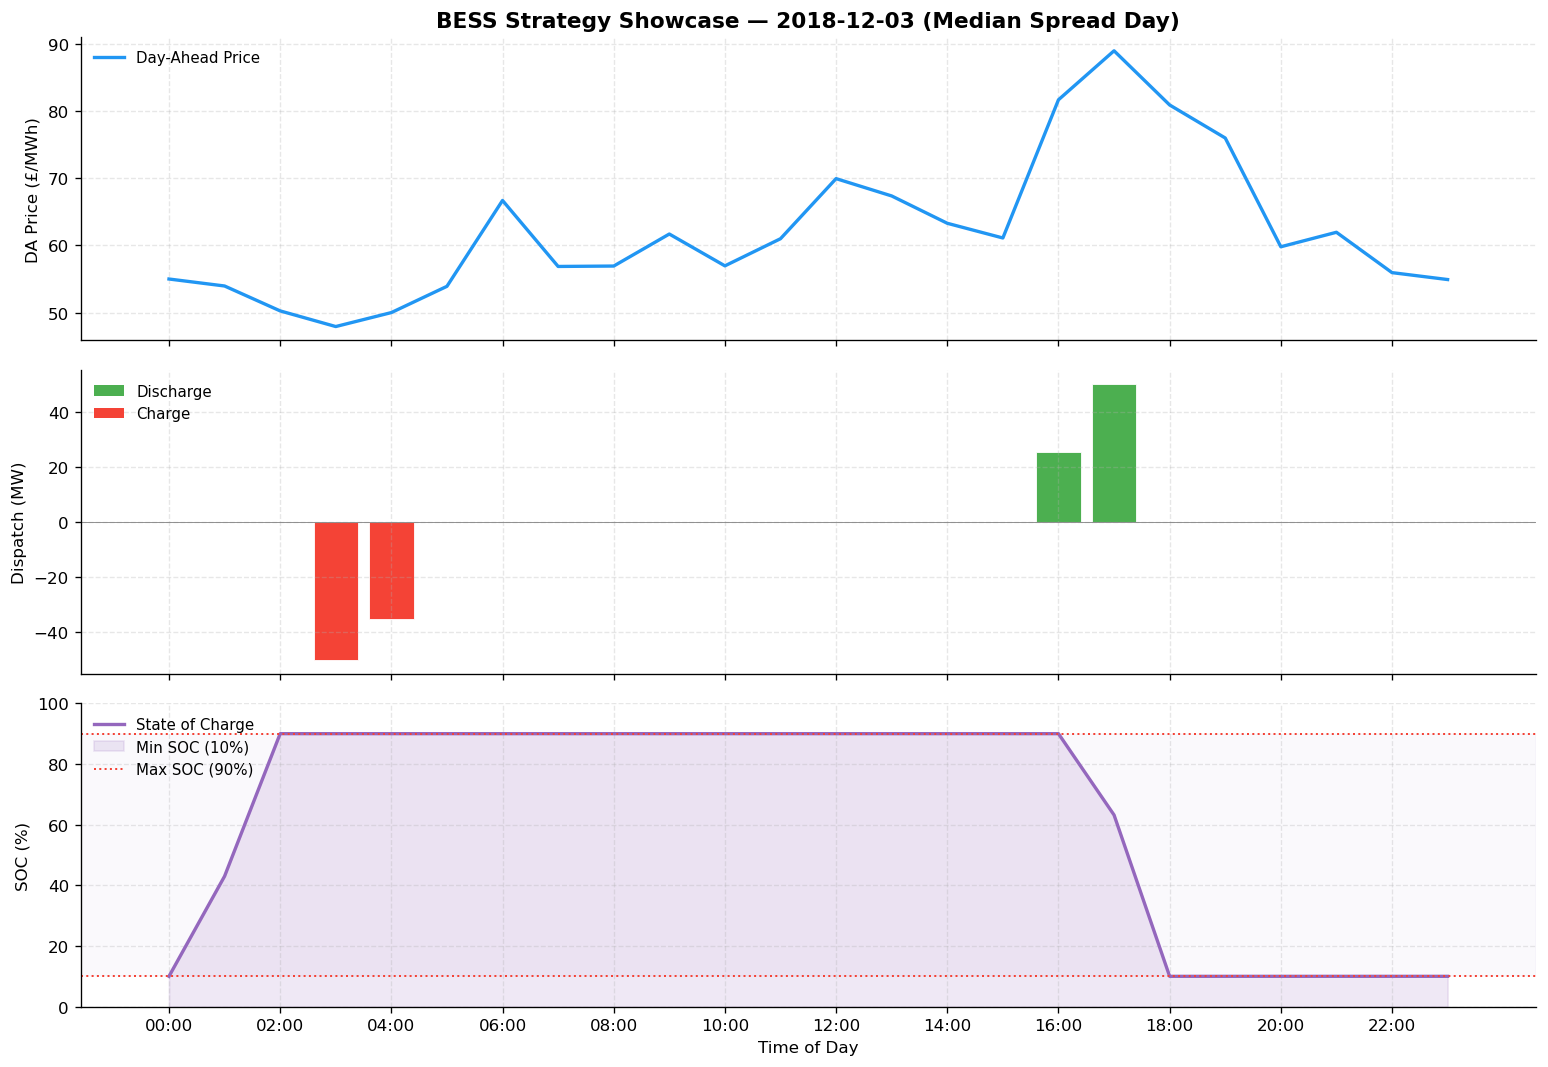

Selected day: 2018-12-03 | DA spread: £41.1/MWh (median: £40.8/MWh)


In [10]:
# Select the day with the median absolute DA spread (representative, not best)
valid_dates = set(da_sched_df["date"].unique())
mask = np.array([d in valid_dates for d in prices.index.date])
valid_prices = prices[mask]
daily_spread = valid_prices.groupby(valid_prices.index.date)["day_ahead_price"].apply(
    lambda x: x.max() - x.min()
)
median_spread = daily_spread.median()
sample_date = daily_spread.iloc[(daily_spread - median_spread).abs().argsort()[:1]].index[0]

# Extract data for the selected day
day_prices = prices.loc[prices.index.date == sample_date]
day_sched = da_sched_df[da_sched_df["date"] == sample_date].sort_values("hour")
day_dispatch = dispatch_df[dispatch_df["date"] == sample_date].sort_values("hour")

da_mw = day_sched["da_mw"].values
n_hours = len(da_mw)
hours = np.arange(n_hours)

soc_series = day_dispatch["soc_after"].values * 100
time_labels = [f"{h:02d}:00" for h in hours]

# ── 3-Panel Figure ────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

ax1.plot(hours, day_prices["day_ahead_price"].values[:n_hours], color=COLORS["da"], linewidth=2)
ax1.set_ylabel("DA Price (£/MWh)")
ax1.set_title(f"BESS Strategy Showcase — {sample_date} (Median Spread Day)", fontsize=13, fontweight="bold")
ax1.legend(["Day-Ahead Price"], frameon=False, fontsize=9, loc="upper left")

bar_colors = [COLORS["intraday"] if mw > 0 else COLORS["imbalance"] if mw < 0 else "#cccccc" for mw in da_mw]
ax2.bar(hours, da_mw, color=bar_colors, width=0.8, edgecolor="white", linewidth=0.5)
ax2.axhline(0, color="grey", linewidth=0.5)
ax2.set_ylabel("Dispatch (MW)")
from matplotlib.patches import Patch
ax2.legend(
    handles=[Patch(facecolor=COLORS["intraday"], label="Discharge"),
             Patch(facecolor=COLORS["imbalance"], label="Charge")],
    frameon=False, fontsize=9, loc="upper left",
)

ax3.plot(hours[:len(soc_series)], soc_series, color="#9467bd", linewidth=2)
ax3.fill_between(hours[:len(soc_series)], 0, soc_series, alpha=0.15, color="#9467bd")
min_soc_line = MIN_SOC_PCT * 100
max_soc_line = MAX_SOC_PCT * 100
ax3.axhline(min_soc_line, color=COLORS["imbalance"], linestyle=":", linewidth=1.2)
ax3.axhline(max_soc_line, color=COLORS["imbalance"], linestyle=":", linewidth=1.2)
ax3.axhspan(min_soc_line, max_soc_line, color="#9467bd", alpha=0.04)
ax3.set_ylim(max(0, min_soc_line - 10), min(100, max_soc_line + 10))
ax3.set_ylabel("SOC (%)")
ax3.set_xlabel("Time of Day")
ax3.legend(
    [
        "State of Charge",
        f"Min SOC ({min_soc_line:.0f}%)",
        f"Max SOC ({max_soc_line:.0f}%)",
    ],
    frameon=False, fontsize=9, loc="upper left",
)

ax3.set_xticks(hours[::2])
ax3.set_xticklabels([time_labels[i] for i in range(0, n_hours, 2)])

plt.tight_layout()
Path("assets").mkdir(exist_ok=True)
plt.show()

print(f"Selected day: {sample_date} | DA spread: £{daily_spread[sample_date]:.1f}/MWh (median: £{median_spread:.1f}/MWh)")

### SOC Health Distribution

A 2D heatmap showing how SOC is distributed across time-of-day over all backtest days. This reveals the **typical SOC envelope** — where the battery spends most of its time at each hour — and highlights structural patterns in the optimiser's charge/discharge schedule.

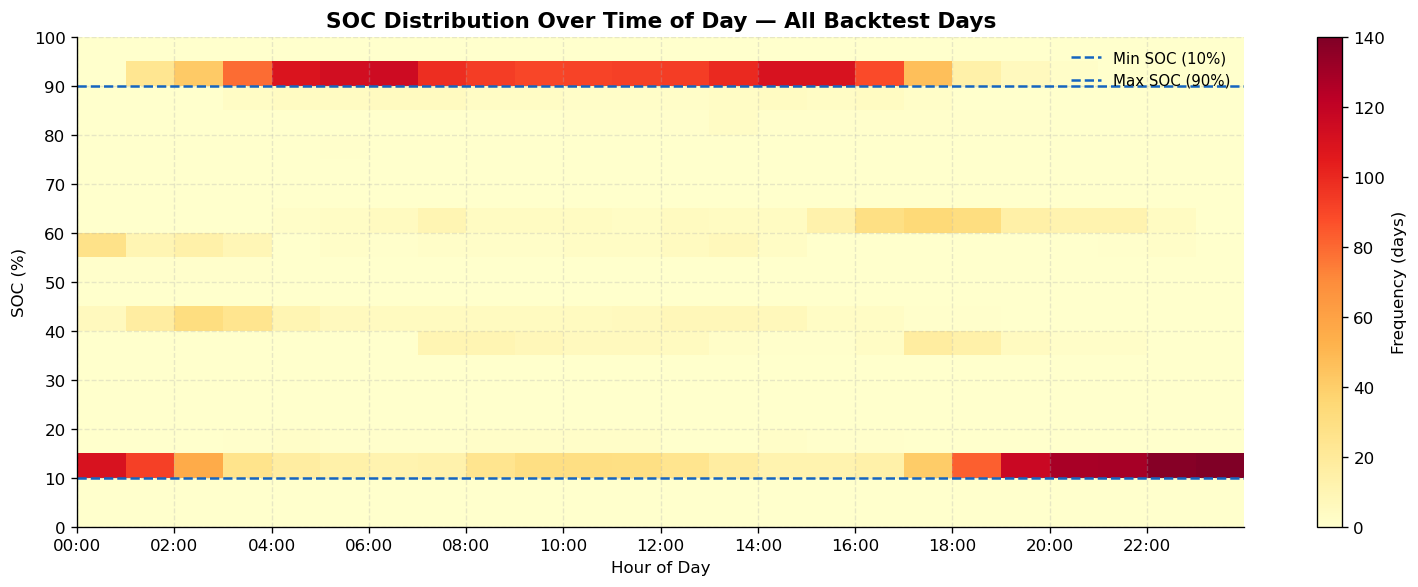

In [11]:
dispatch_df["timestamp"] = pd.to_datetime(dispatch_df["timestamp"])
soc_pct = dispatch_df["soc_after"].values * 100
hour_of_day = dispatch_df["hour"].values

soc_bins = np.arange(0, 105, 5)
hour_bins = np.arange(0, 25)

hist, xedges, yedges = np.histogram2d(hour_of_day, soc_pct, bins=[hour_bins, soc_bins])

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.pcolormesh(xedges, yedges, hist.T, cmap="YlOrRd", shading="flat")
fig.colorbar(im, ax=ax, label="Frequency (days)")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("SOC (%)")
ax.set_title("SOC Distribution Over Time of Day — All Backtest Days", fontsize=13, fontweight="bold")
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])
ax.set_yticks(range(0, 101, 10))

# Overlay the operating SOC bounds — battery is constrained to this band
min_soc_line = MIN_SOC_PCT * 100
max_soc_line = MAX_SOC_PCT * 100
ax.axhline(min_soc_line, color="#1565C0", linestyle="--", linewidth=1.5,
           label=f"Min SOC ({min_soc_line:.0f}%)")
ax.axhline(max_soc_line, color="#1565C0", linestyle="--", linewidth=1.5,
           label=f"Max SOC ({max_soc_line:.0f}%)")
ax.legend(frameon=False, fontsize=9, loc="upper right")

plt.tight_layout()
plt.show()

### Rebalancing Impact — DA Schedule vs. Final Dispatch

Compares the LP-committed DA schedule with the actual dispatch (after intraday rebalancing) for the same sample day. The gap between the two series shows where the intraday rules engine adjusted volume.

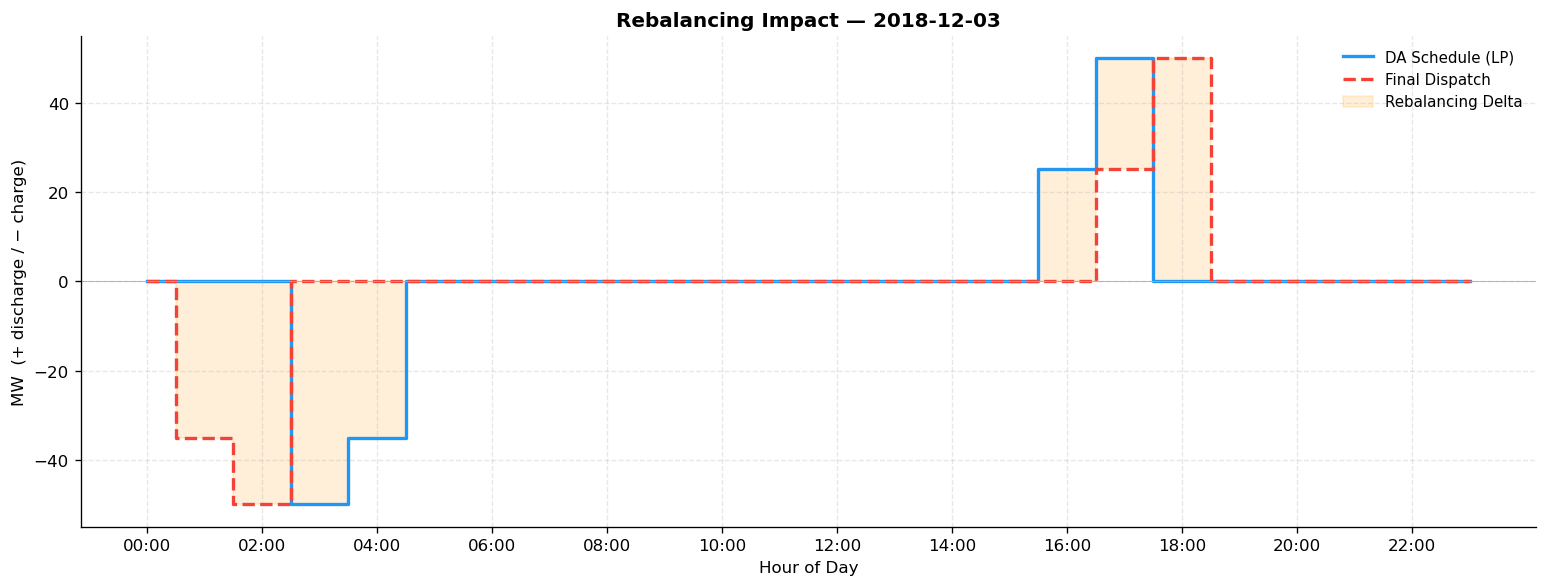

In [12]:
# Re-derive sample-day data so this cell is safe to run independently
day_sched_s  = da_sched_df[da_sched_df["date"] == sample_date].sort_values("hour")
day_disp_s   = dispatch_df[dispatch_df["date"] == sample_date].sort_values("hour")
da_mw_s      = day_sched_s["da_mw"].values
hours_s      = np.arange(len(da_mw_s))

actual_mw = []
for _, row in day_disp_s.iterrows():
    if row["action"] == "discharge":
        actual_mw.append(row["mw"])
    elif row["action"] == "charge":
        actual_mw.append(-row["mw"])
    else:
        actual_mw.append(0.0)
actual_mw = np.array(actual_mw)

fig, ax = plt.subplots(figsize=(13, 5))
ax.step(hours_s, da_mw_s,   where="mid", linewidth=2,   color=COLORS["da"],       label="DA Schedule (LP)")
ax.step(hours_s, actual_mw, where="mid", linewidth=2,   color=COLORS["imbalance"],
        linestyle="--", label="Final Dispatch")
ax.fill_between(hours_s, da_mw_s, actual_mw, alpha=0.15, color=COLORS["degradation"],
                step="mid", label="Rebalancing Delta")
ax.axhline(0, color="#aaaaaa", linewidth=0.5)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("MW  (+ discharge / − charge)")
ax.set_title(f"Rebalancing Impact — {sample_date}", fontsize=12, fontweight="bold")
ax.set_xticks(hours_s[::2])
ax.set_xticklabels([f"{h:02d}:00" for h in hours_s[::2]])
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


### Dispatch Efficiency

Compares the DA-committed MW schedule with the actual dispatched MW for every period in the backtest. Points on the diagonal indicate perfect execution.

,Value
Metric,
Mean Absolute Deviation,7.220 MW
Periods within ±5% of 50.0 MW,79.8%
Total periods evaluated,"3,452"


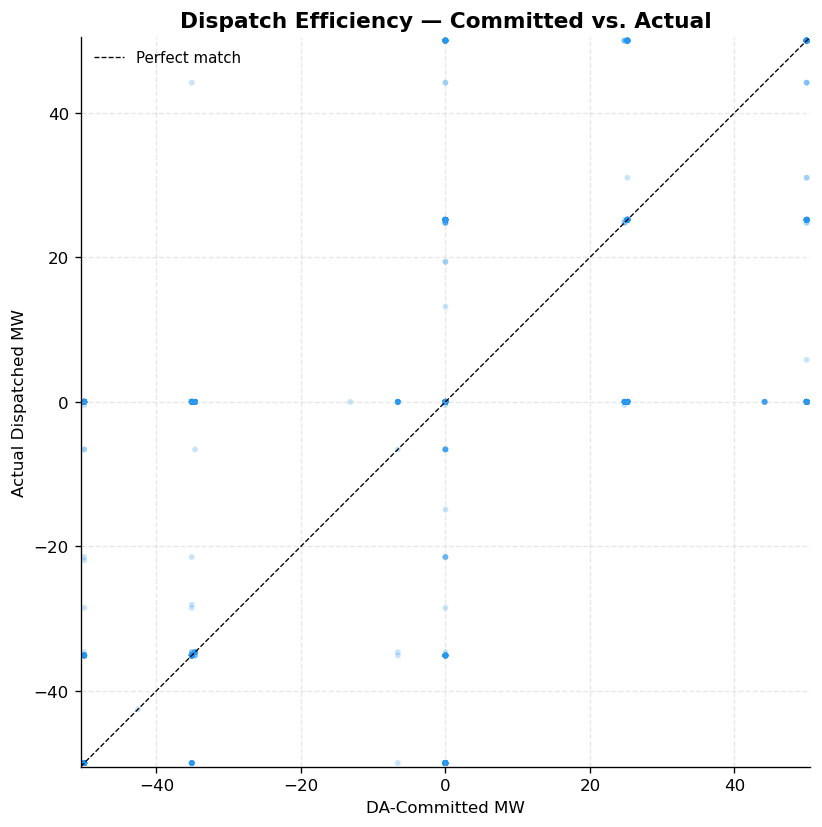

In [13]:
efficiency = da_sched_df.merge(
    dispatch_df[["date", "hour", "action", "mw"]],
    on=["date", "hour"],
    how="inner",
)
efficiency["actual_mw"] = np.where(
    efficiency["action"] == "discharge", efficiency["mw"],
    np.where(efficiency["action"] == "charge", -efficiency["mw"], 0.0),
)
efficiency["deviation"] = efficiency["actual_mw"] - efficiency["da_mw"]

mad = efficiency["deviation"].abs().mean()
power_mw = BESS_CFG["power_mw"]
within_5 = (efficiency["deviation"].abs() <= 0.05 * power_mw).mean() * 100

metrics = pd.DataFrame([
    {"Metric": "Mean Absolute Deviation",               "Value": f"{mad:.3f} MW"},
    {"Metric": f"Periods within ±5% of {power_mw} MW",  "Value": f"{within_5:.1f}%"},
    {"Metric": "Total periods evaluated",                "Value": f"{len(efficiency):,}"},
]).set_index("Metric")
display(metrics.style.set_properties(**{"text-align": "right"}))

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(efficiency["da_mw"], efficiency["actual_mw"],
           alpha=0.25, s=12, color=COLORS["da"], edgecolors="none")
lims = [
    min(efficiency["da_mw"].min(), efficiency["actual_mw"].min()) - 0.5,
    max(efficiency["da_mw"].max(), efficiency["actual_mw"].max()) + 0.5,
]
ax.plot(lims, lims, "k--", linewidth=0.8, label="Perfect match")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("DA-Committed MW")
ax.set_ylabel("Actual Dispatched MW")
ax.set_title("Dispatch Efficiency — Committed vs. Actual", fontsize=13, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

### Price Capture Analysis

Shows when (by hour of day) the BESS charges vs. discharges relative to the average DA price profile. A well-optimised BESS should discharge at high-price hours and charge at low-price hours. The spread between the weighted-average discharge price and the weighted-average charge price is the **achieved price spread** — the key driver of DA revenue.


Weighted avg discharge price : £83.00/MWh
Weighted avg charge price    : £50.36/MWh
Achieved price spread        : £32.64/MWh
All-day average DA price     : £62.71/MWh


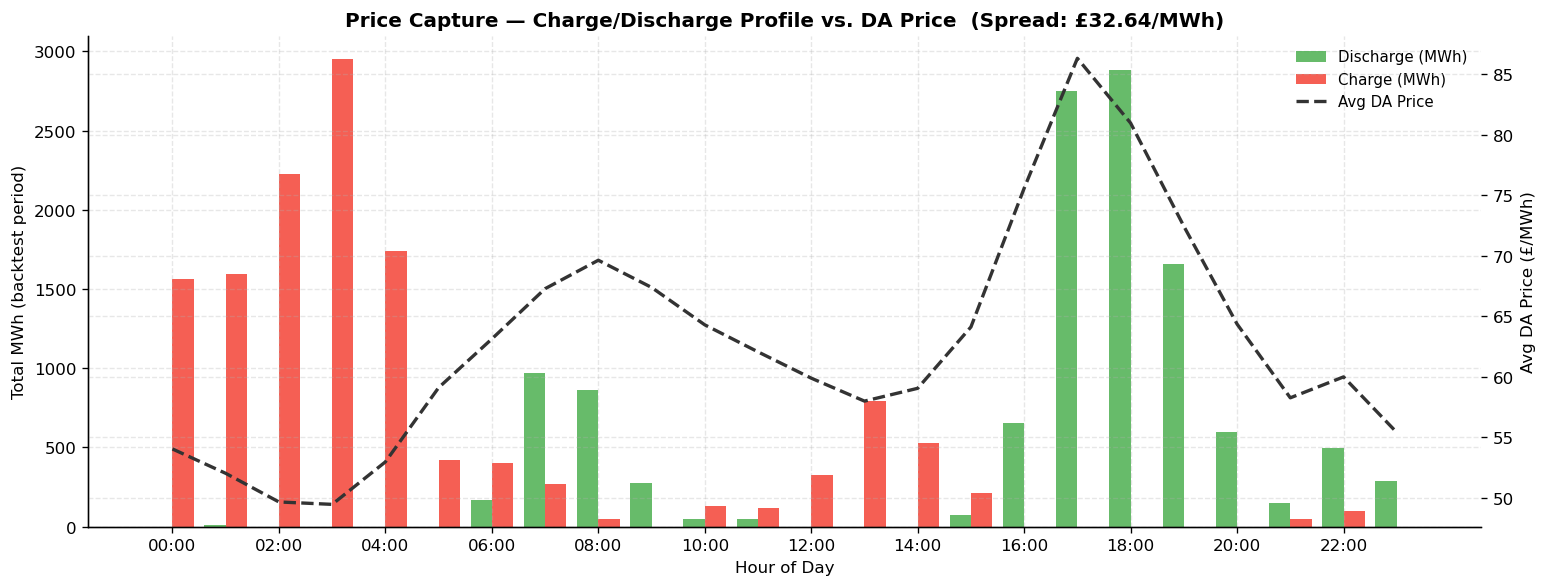

In [14]:
# ── Dispatch by hour of day ────────────────────────────────────────────────────
_ddf = dispatch_df.copy()
_ddf["hod"] = _ddf["hour"]

discharge_mwh = _ddf[_ddf["action"] == "discharge"].groupby("hod")["mw"].sum()
charge_mwh    = _ddf[_ddf["action"] == "charge"].groupby("hod")["mw"].sum()

# Average DA price by hour (across the full analysis period)
prices_hod = prices.copy()
prices_hod["hod"] = prices_hod.index.hour
avg_da_by_hour = prices_hod.groupby("hod")["day_ahead_price"].mean()

# Weighted average charge and discharge prices
_ddf2 = dispatch_df.merge(
    prices[["day_ahead_price"]].rename(columns={"day_ahead_price": "da_p"}),
    left_on="timestamp", right_index=True, how="left",
)
w_discharge = (_ddf2[_ddf2["action"] == "discharge"]["da_p"] * _ddf2[_ddf2["action"] == "discharge"]["mw"]).sum() \
              / _ddf2[_ddf2["action"] == "discharge"]["mw"].sum()
w_charge    = (_ddf2[_ddf2["action"] == "charge"]["da_p"] * _ddf2[_ddf2["action"] == "charge"]["mw"]).sum() \
              / _ddf2[_ddf2["action"] == "charge"]["mw"].sum()
price_spread = w_discharge - w_charge

print(f"Weighted avg discharge price : £{w_discharge:.2f}/MWh")
print(f"Weighted avg charge price    : £{w_charge:.2f}/MWh")
print(f"Achieved price spread        : £{price_spread:.2f}/MWh")
print(f"All-day average DA price     : £{avg_da_by_hour.mean():.2f}/MWh")

# ── Chart ──────────────────────────────────────────────────────────────────────
hod_x = np.arange(24)
fig, ax1 = plt.subplots(figsize=(13, 5))

ax2 = ax1.twinx()
ax2.plot(avg_da_by_hour.reindex(hod_x, fill_value=0).index,
         avg_da_by_hour.reindex(hod_x, fill_value=0).values,
         color="#333333", linewidth=2, linestyle="--", label="Avg DA Price", zorder=5)
ax2.set_ylabel("Avg DA Price (£/MWh)", fontsize=10)
ax2.spines["top"].set_visible(False)

w = 0.4
ax1.bar(hod_x - w/2, discharge_mwh.reindex(hod_x, fill_value=0),
        w, color=COLORS["intraday"], alpha=0.85, label="Discharge (MWh)")
ax1.bar(hod_x + w/2, charge_mwh.reindex(hod_x, fill_value=0),
        w, color=COLORS["imbalance"], alpha=0.85, label="Charge (MWh)")

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Total MWh (backtest period)", fontsize=10)
ax1.set_xticks(hod_x[::2])
ax1.set_xticklabels([f"{h:02d}:00" for h in hod_x[::2]])
ax1.set_title(
    f"Price Capture — Charge/Discharge Profile vs. DA Price  "
    f"(Spread: £{price_spread:.2f}/MWh)",
    fontsize=12, fontweight="bold",
)
ax1.axhline(0, color="#aaaaaa", linewidth=0.5)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, frameon=False, fontsize=9)
plt.tight_layout()
plt.show()


### Intraday Re-optimisation Footprint

Each point is a delivery period where the rolling LP **deviated** the physical
dispatch from the locked DA plan (`intraday_mw ≠ 0`). The decision is made on
the DA proxy, but the deviation **settles at the real MID**. The x-axis is the
realised DA price; the y-axis is the signed deviation (+ extra discharge /
− extra charge). The engine sells into rich periods and buys in cheap ones —
correcting the forecast-based schedule, only when the move beats the basis +
execution + wear hurdle.

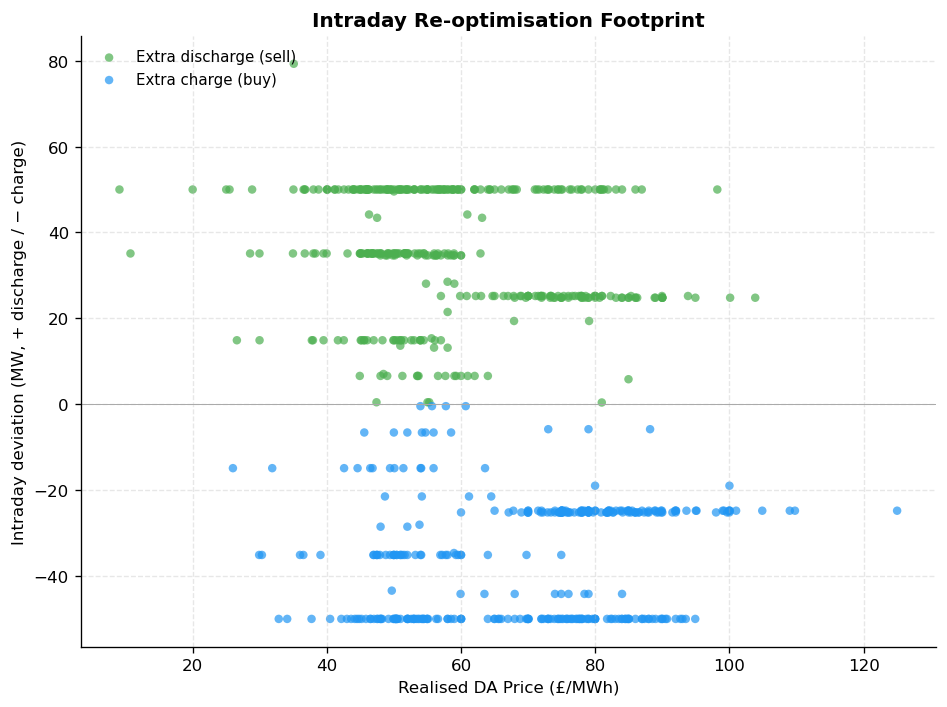

In [15]:
# ── Where the re-optimisation deviated from the locked DA plan ──
dev_col = "intraday_mw" if "intraday_mw" in dispatch_df else "spread_mw"
dev_trades = dispatch_df[dispatch_df[dev_col].abs() > 1e-6].dropna(
    subset=["da_price_actual", dev_col]
)

fig, ax = plt.subplots(figsize=(8, 6))
if len(dev_trades) == 0:
    ax.text(0.5, 0.5, "No intraday deviations in this run",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=11, color="#888888")
    ax.set_axis_off()
else:
    sells = dev_trades[dev_trades[dev_col] > 0]
    buys  = dev_trades[dev_trades[dev_col] < 0]
    ax.scatter(sells["da_price_actual"], sells[dev_col], s=26, alpha=0.7,
               color=COLORS["intraday"], edgecolors="none", label="Extra discharge (sell)")
    ax.scatter(buys["da_price_actual"], buys[dev_col], s=26, alpha=0.7,
               color=COLORS["da"], edgecolors="none", label="Extra charge (buy)")
    ax.axhline(0, color="#aaaaaa", linewidth=0.6)
    ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_xlabel("Realised DA Price (£/MWh)")
ax.set_ylabel("Intraday deviation (MW, + discharge / − charge)")
ax.set_title("Intraday Re-optimisation Footprint", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Section 4: Risk Profile

Four-panel risk dashboard: rolling 30-day Sharpe ratio, daily drawdown, daily PnL distribution, and PnL waterfall decomposition.


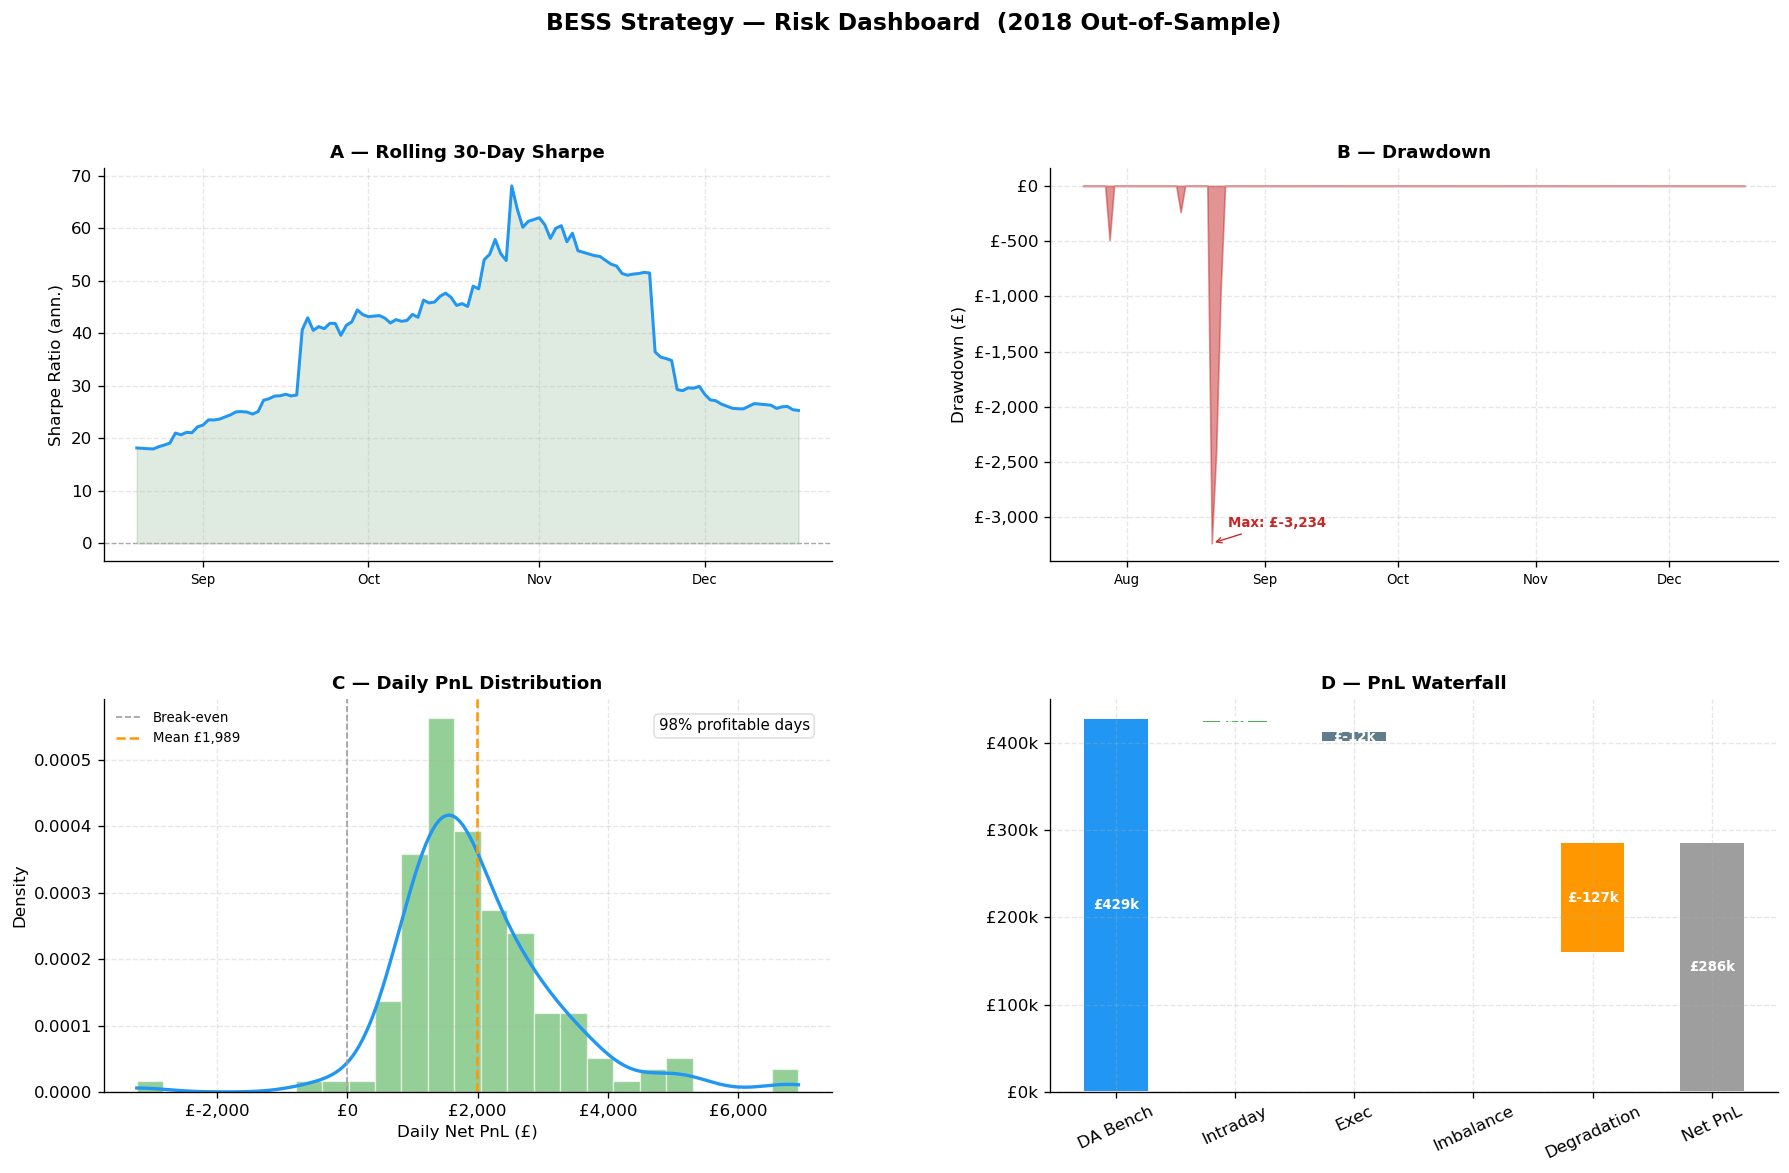

In [16]:
import matplotlib.gridspec as gridspec

# ── Pre-compute rolling metrics ────────────────────────────────────────────────
_pnl_series = results_df.set_index("date")["net_pnl"]
_rolling_w  = 30
_roll_mean  = _pnl_series.rolling(_rolling_w).mean()
_roll_std   = _pnl_series.rolling(_rolling_w).std(ddof=1)
_roll_sharpe = (_roll_mean / _roll_std) * np.sqrt(365)

_equity = STARTING_CAPITAL + _pnl_series.cumsum()
_dd     = _equity - _equity.cummax()

# ── Four-panel figure ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])   # Rolling Sharpe
ax2 = fig.add_subplot(gs[0, 1])   # Drawdown
ax3 = fig.add_subplot(gs[1, 0])   # Daily PnL distribution
ax4 = fig.add_subplot(gs[1, 1])   # PnL waterfall

# ── A: Rolling 30-Day Sharpe ──────────────────────────────────────────────────
ax1.plot(_roll_sharpe.index, _roll_sharpe.values, color=COLORS["da"], linewidth=1.8)
ax1.fill_between(_roll_sharpe.index, 0, _roll_sharpe.values,
                 where=(_roll_sharpe.values >= 0), alpha=0.15, color="#2E7D32")
ax1.fill_between(_roll_sharpe.index, 0, _roll_sharpe.values,
                 where=(_roll_sharpe.values < 0),  alpha=0.15, color="#C62828")
ax1.axhline(0, color="#aaaaaa", linewidth=0.8, linestyle="--")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.set_title(f"A — Rolling {_rolling_w}-Day Sharpe", fontsize=11, fontweight="bold")
ax1.set_ylabel("Sharpe Ratio (ann.)")
ax1.tick_params(axis="x", labelsize=8)

# ── B: Drawdown ───────────────────────────────────────────────────────────────
ax2.fill_between(_dd.index, _dd.values, 0, alpha=0.5, color="#C62828")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax2.set_title("B — Drawdown", fontsize=11, fontweight="bold")
ax2.set_ylabel("Drawdown (£)")
ax2.tick_params(axis="x", labelsize=8)
ax2.annotate(f"Max: £{_dd.min():,.0f}",
             xy=(_dd.index[_dd.argmin()], _dd.min()),
             xytext=(10, 10), textcoords="offset points",
             fontsize=8, color="#C62828", fontweight="bold",
             arrowprops=dict(arrowstyle="->", color="#C62828", lw=0.8))

# ── C: Daily PnL distribution ─────────────────────────────────────────────────
_dpnl = results_df["net_pnl"].values
_mean = _dpnl.mean()
_pct_pos = (_dpnl > 0).mean() * 100

ax3.hist(_dpnl, bins=25, density=True, alpha=0.6, color=COLORS["intraday"],
         edgecolor="white", linewidth=0.8)
_x_kde = np.linspace(_dpnl.min(), _dpnl.max(), 200)
ax3.plot(_x_kde, gaussian_kde(_dpnl)(_x_kde), linewidth=2, color=COLORS["da"])
ax3.axvline(0,      color=COLORS["net"],         linewidth=1, linestyle="--", label="Break-even")
ax3.axvline(_mean,  color=COLORS["degradation"], linewidth=1.5, linestyle="--",
            label=f"Mean £{_mean:,.0f}")
ax3.set_xlabel("Daily Net PnL (£)")
ax3.set_ylabel("Density")
ax3.set_title("C — Daily PnL Distribution", fontsize=11, fontweight="bold")
ax3.legend(frameon=False, fontsize=8)
ax3.text(0.97, 0.95, f"{_pct_pos:.0f}% profitable days",
         transform=ax3.transAxes, ha="right", va="top", fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#dddddd", alpha=0.9))
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

# ── D: PnL waterfall decomposition (Trader's ledger) ───────────────────────────
_wf = {
    "DA Bench":    results_df["benchmark_da_revenue"].sum(),
    "Intraday":    results_df["intraday_da_improvement"].sum(),
    "Exec":        -results_df["execution_costs_paid"].sum(),
    "Imbalance":   results_df["imbalance_pnl"].sum(),
    "Degradation": -results_df["degradation_cost"].sum(),
}
_wf_net = sum(_wf.values())
_wf_labels = list(_wf.keys()) + ["Net PnL"]
_wf_values = list(_wf.values()) + [_wf_net]

_run = 0.0; _bots = []
for v in list(_wf.values()):
    _bots.append(_run if v >= 0 else _run + v)
    _run += v
_bots.append(0.0)

_wf_colors = [COLORS["da"], COLORS["intraday"],
              "#607D8B", COLORS["imbalance"], COLORS["degradation"], COLORS["net"]]
bars = ax4.bar(_wf_labels, _wf_values, bottom=_bots, color=_wf_colors, width=0.55,
               edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, _wf_values):
    y = bar.get_y() + bar.get_height() / 2
    ax4.text(bar.get_x() + bar.get_width() / 2, y, f"£{val/1000:.0f}k",
             ha="center", va="center", fontsize=8, fontweight="bold", color="white")
ax4.axhline(0, color="#aaaaaa", linewidth=0.5)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1000:.0f}k"))
ax4.set_title("D — PnL Waterfall", fontsize=11, fontweight="bold")
ax4.tick_params(axis="x", rotation=25)

fig.suptitle("BESS Strategy — Risk Dashboard  (2018 Out-of-Sample)",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()

---
## Section 5: Rolling-Horizon Re-Optimisation Engine

The intraday engine (`intraday_manager.py`) re-optimises the **physical** schedule
over the remaining horizon while the day-ahead financial position stays locked.
The continuous-market MID is not observable, so it is **proxied from the cleared
DA price** (± the `margin_sell` / `margin_buy` basis); an LP then chooses the
physical dispatch that maximises the value of deviations from the locked plan,
net of the basis, execution friction and degradation:

    max Σ [ dev⁺·(DA − margin_sell) − dev⁻·(DA + margin_buy)
            − (dev⁺ + dev⁻)·exec − (charge + discharge)·deg ] · duration

Under this phase's static information set (all of D's DA prices clear before
delivery), the rolling re-solve collapses to a single full-day optimisation. This
section parses the `dispatch_log` per-period `trade_type` tag (`reopt_sell`,
`reopt_buy`, `physical_dispatch`, `idle`) and the deviation it booked.

In [17]:
# ── Parse the dispatch_log: re-optimisation deviations by trade_type ──
dev_col = "intraday_mw" if "intraday_mw" in dispatch_df else "spread_mw"
log = dispatch_df.copy()
log["abs_dev_mwh"] = log[dev_col].abs()

trade_breakdown = (
    log.groupby("trade_type")
    .agg(periods=("period", "size"),
         deviated_mwh=("abs_dev_mwh", "sum"))
    .reindex(["physical_dispatch", "reopt_sell", "reopt_buy", "idle"])
    .dropna(how="all")
)
trade_breakdown["share_of_periods"] = (
    trade_breakdown["periods"] / trade_breakdown["periods"].sum() * 100
)
display(
    trade_breakdown.style
    .format({"periods": "{:,.0f}", "deviated_mwh": "{:,.1f} MWh",
             "share_of_periods": "{:.1f}%"}, na_rep="—")
    .set_properties(**{"text-align": "right"})
)

total_improvement = results_df["intraday_da_improvement"].sum()
total_execution   = results_df["execution_costs_paid"].sum()
total_saved_mwh   = results_df["cycles_saved_mwh"].sum()
deg_per_mwh       = BESS_CFG["degradation_cost_per_mwh"]

print(f"Intraday DA improvement (gross)   : £{total_improvement:,.0f}")
print(f"Execution friction paid           : £{total_execution:,.0f}")
print(f"Intraday improvement (net of exec): £{total_improvement - total_execution:,.0f}")
print(f"Wear avoided vs benchmark plan     : {total_saved_mwh:,.1f} MWh "
      f"(≈ £{total_saved_mwh * deg_per_mwh:,.0f} @ £{deg_per_mwh:.2f}/MWh)")

,periods,deviated_mwh,share_of_periods
trade_type,,,
physical_dispatch,288,0.0 MWh,8.3%
reopt_sell,360,"12,630.8 MWh",10.4%
reopt_buy,346,"12,293.5 MWh",10.0%
idle,"2,458",0.0 MWh,71.2%


Intraday DA improvement (gross)   : £-3,162
Execution friction paid           : £12,462
Intraday improvement (net of exec): £-15,624
Wear avoided vs benchmark plan     : 6,129.7 MWh (≈ £30,648 @ £5.00/MWh)


### Re-optimisation Deviation by Hour of Day

When does the rolling LP step away from the locked DA plan? This shows the mean
signed intraday deviation by hour of day (+ extra discharge / − extra charge) —
the systematic shape of how realised prices pull the schedule away from the
forecast-based commitment.

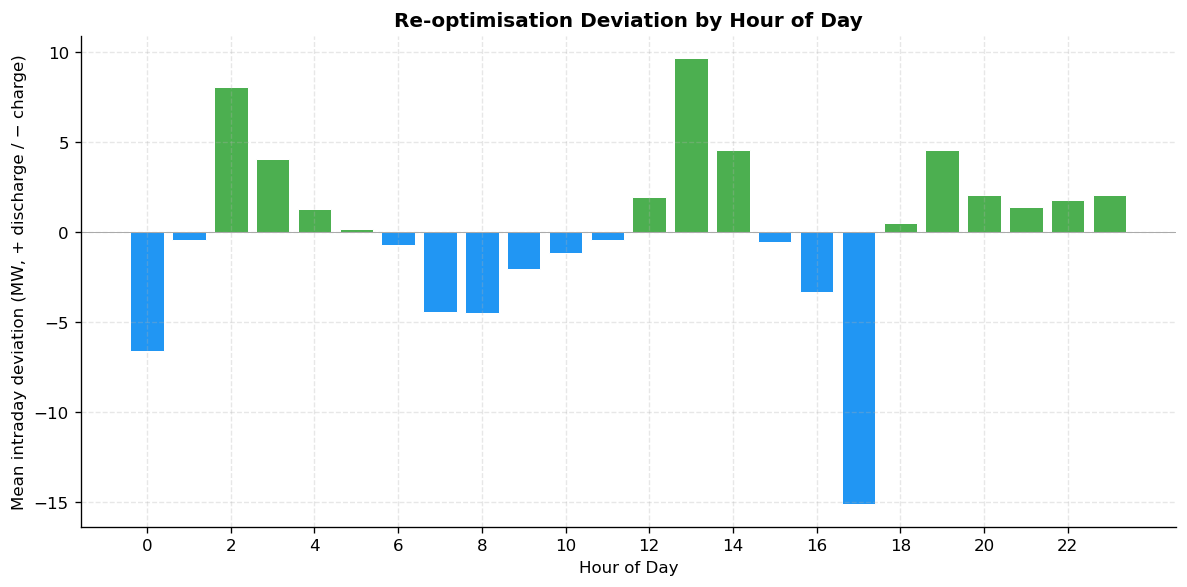

Periods with an intraday deviation : 706 of 3,452 (20.5%)


In [18]:
# ── Mean intraday deviation by hour of day ──
dev_col = "intraday_mw" if "intraday_mw" in dispatch_df else "spread_mw"
d = dispatch_df.copy()
d["timestamp"] = pd.to_datetime(d["timestamp"])
d["hod"] = d["timestamp"].dt.hour
by_hour = d.groupby("hod")[dev_col].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS["intraday"] if v >= 0 else COLORS["da"] for v in by_hour.values]
ax.bar(by_hour.index, by_hour.values, color=colors, edgecolor="white", linewidth=0.6)
ax.axhline(0, color="#aaaaaa", linewidth=0.6)
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean intraday deviation (MW, + discharge / − charge)")
ax.set_title("Re-optimisation Deviation by Hour of Day", fontsize=12, fontweight="bold")
ax.set_xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

n_dev = int((d[dev_col].abs() > 1e-6).sum())
print(f"Periods with an intraday deviation : {n_dev:,} of {len(d):,} "
      f"({n_dev / len(d) * 100:.1f}%)")

### Imbalance Leakage — Projected-to-Feasible Schedule

The rolling re-optimisation projects its net schedule onto the exact SOC bounds
before dispatch, so the battery never commits energy it cannot physically deliver
or absorb. Total **Imbalance PnL** is therefore ≈ £0 by construction in this
phase — there is no end-of-day SBP/SSP leakage. (Forecast-error-driven imbalance
re-enters in Phase 4, once a live MID forecast can diverge from realised prices.)

This chart shows the realised Imbalance PnL from the backtest
(`results_df["imbalance_pnl"]`); if a pre-refactor total is checkpointed at
`bess/pre_refactor_imbalance.json` it is shown alongside for comparison.

Rolling re-opt Imbalance PnL : £0 (≈ 0 by construction)


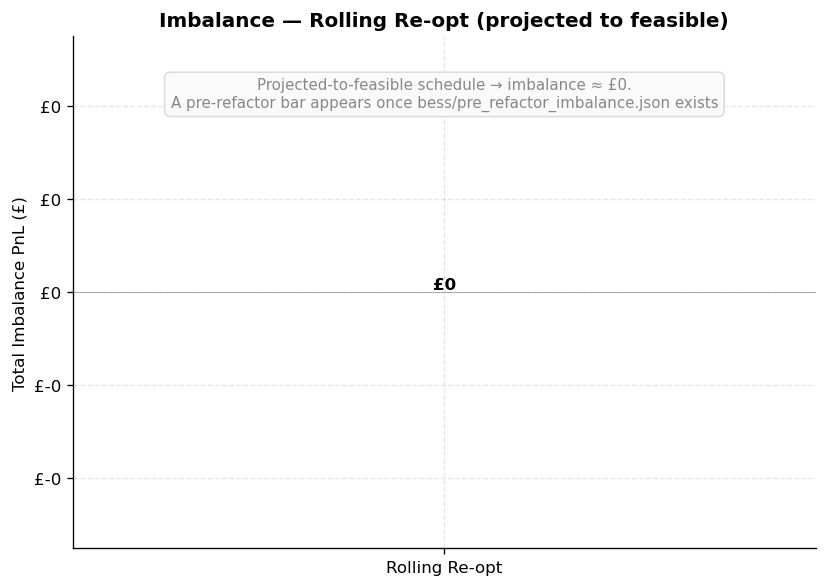

In [19]:
# ── Imbalance PnL: rolling re-opt engine (projected to feasible) ───────────
new_imbalance = results_df["imbalance_pnl"].sum()

# Look for a checkpointed pre-refactor imbalance total; render note if absent.
_pre_path = ARTIFACT_DIR / "bess" / "pre_refactor_imbalance.json"
old_imbalance = (
    _json.loads(_pre_path.read_text()).get("imbalance_pnl")
    if _pre_path.exists() else None
)

fig, ax = plt.subplots(figsize=(7, 5))

if old_imbalance is None:
    ax.bar(["Rolling Re-opt"], [new_imbalance], width=0.5,
           color=COLORS["intraday"], edgecolor="white", linewidth=1.5)
    ax.text(0, new_imbalance, f"£{new_imbalance:,.0f}",
            ha="center", va="bottom" if new_imbalance >= 0 else "top",
            fontsize=10, fontweight="bold")
    ax.text(0.5, 0.92,
            "Projected-to-feasible schedule → imbalance ≈ £0.\n"
            "A pre-refactor bar appears once "
            "bess/pre_refactor_imbalance.json exists",
            transform=ax.transAxes, ha="center", va="top", fontsize=9,
            color="#888888",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#fafafa",
                      edgecolor="#dddddd"))
    print(f"Rolling re-opt Imbalance PnL : £{new_imbalance:,.0f} (≈ 0 by construction)")
else:
    bars = ax.bar(["Pre-refactor", "Rolling Re-opt"],
                  [old_imbalance, new_imbalance], width=0.55,
                  color=[COLORS["imbalance"], COLORS["intraday"]],
                  edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, [old_imbalance, new_imbalance]):
        ax.text(bar.get_x() + bar.get_width() / 2, val,
                f"£{val:,.0f}", ha="center",
                va="bottom" if val >= 0 else "top",
                fontsize=10, fontweight="bold")
    leakage_removed = new_imbalance - old_imbalance
    print(f"Pre-refactor Imbalance PnL  : £{old_imbalance:,.0f}")
    print(f"Rolling re-opt Imbalance PnL : £{new_imbalance:,.0f}")
    print(f"Leakage removed             : £{leakage_removed:,.0f}")

ax.axhline(0, color="#aaaaaa", linewidth=0.6)
ax.set_ylabel("Total Imbalance PnL (£)")
ax.set_title("Imbalance — Rolling Re-opt (projected to feasible)",
             fontsize=12, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.tight_layout()
plt.show()